In [63]:
import pandas as pd 
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
# import seaborn as sns

In [36]:
from pathlib import Path
from torchvision.datasets import EuroSAT

In [37]:
#download the data:
data_dir_path = Path("../data/EuroSAT")

dataset = EuroSAT(
    root=data_dir_path,
    download=True,
)

In [ ]:
# create a df of the data:
data_path = Path(data_dir_path) / "eurosat" / "2750"
classes_dir_paths = data_path.iterdir()

paths = []
labels = []
for class_dir_path in classes_dir_paths:
    img_paths = list(class_dir_path.glob("*.jpg"))
    paths.extend(img_paths)
    labels.extend([class_dir_path.stem] * len(img_paths))

df = pd.DataFrame({"image_path": paths, "label": labels})

In [39]:
df.shape

(27000, 2)

In [40]:
df.head()

,image_path,label
0,../data/EuroSAT/eurosat/2750/Residential/Resid...,Residential
1,../data/EuroSAT/eurosat/2750/Residential/Resid...,Residential
2,../data/EuroSAT/eurosat/2750/Residential/Resid...,Residential
3,../data/EuroSAT/eurosat/2750/Residential/Resid...,Residential
4,../data/EuroSAT/eurosat/2750/Residential/Resid...,Residential


In [41]:
df.label.value_counts()

label
Residential             3000
AnnualCrop              3000
SeaLake                 3000
HerbaceousVegetation    3000
Forest                  3000
PermanentCrop           2500
Highway                 2500
River                   2500
Industrial              2500
Pasture                 2000
Name: count, dtype: int64

In [44]:
classes = list(df.label.unique())
classes

['Residential',
 'AnnualCrop',
 'PermanentCrop',
 'Highway',
 'River',
 'Industrial',
 'Pasture',
 'SeaLake',
 'HerbaceousVegetation',
 'Forest']

In [45]:
num_samples = 3
samples_per_label = [df[df.label==label].sample(n=num_samples) for label in classes]

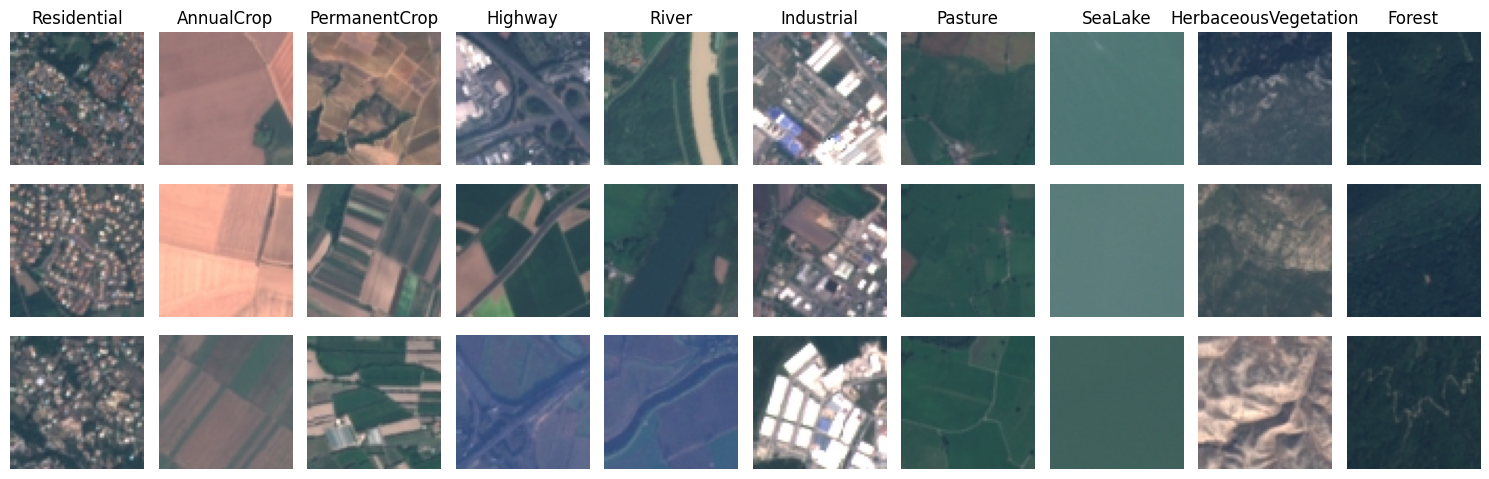

In [62]:
fig, axes = plt.subplots(3, 10, sharey=True, figsize=(15, 5))
for col, label_sample in enumerate(samples_per_label):
    axes[0, col].set_title(label_sample.label.iloc[0], fontsize=12)
    for sample_idx, (_, row) in enumerate(label_sample.iterrows
                                          ()):
        img = Image.open(row.image_path)
        axes[sample_idx, col].imshow(img)
        # axes[sample_idx, col].set_title(row.label)
        axes[sample_idx, col].axis("off")

plt.tight_layout()
plt.show()

Colors curiocity: what's the median of R, G, B for each class?

In [66]:
medians_R = []
medians_G = []
medians_B = []
for label in classes:
    # compute median pixel value for each channel for each label, computed from a sample of 100 images per label:
    label_df = df[df.label == label]
    label_sample_df = label_df.sample(n=100)

    pixel_values_R = []
    pixel_values_G = []
    pixel_values_B = []
    for _, row in label_sample_df.iterrows():
        img = Image.open(row.image_path)
        img_array = np.array(img)
        pixel_values_R.extend(img_array[:, :, 0].flatten())
        pixel_values_G.extend(img_array[:, :, 1].flatten())
        pixel_values_B.extend(img_array[:, :, 2].flatten())
    medians_R.append(np.median(pixel_values_R))
    medians_G.append(np.median(pixel_values_G))
    medians_B.append(np.median(pixel_values_B))

median_values_table = pd.DataFrame({"label": classes, "median_R": medians_R, "median_G": medians_G, "median_B": medians_B})
median_values_table

,label,median_R,median_G,median_B
0,Residential,91.0,97.0,109.0
1,AnnualCrop,124.0,115.0,113.0
2,PermanentCrop,111.0,106.0,106.0
3,Highway,78.0,91.0,98.0
4,River,56.0,83.0,92.0
5,Industrial,111.0,112.0,122.0
6,Pasture,58.0,87.0,88.0
7,SeaLake,39.0,64.0,84.0
8,HerbaceousVegetation,87.0,90.0,96.0
9,Forest,37.0,63.0,74.0
